<a href="https://colab.research.google.com/github/haMC365/transformer_sat/blob/main/version_Helios_2025/Transformer_SAT_Helios_v2025_Stage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Génération de SAT aléatoire**

Génère un nombre N d'instances SAT aléatoires au format .cnf et les stocke dans /content/generated_3sat

In [ ]:
!pip install python-sat
!rm -rf /content/generated_3sat
!mkdir /content/generated_3sat

import random
import os
import hashlib
from pysat.formula import CNF
from pysat.solvers import Solver

def generate_random_3sat(n_vars, n_clauses):
    cnf = CNF()
    while len(cnf.clauses) < n_clauses:
        clause = random.sample(range(1, n_vars + 1), 3)
        clause = [x if random.choice([True, False]) else -x for x in clause]
        cnf.append(clause)
    return cnf

def cnf_hash(cnf):
    normalized_clauses = [tuple(sorted(clause)) for clause in cnf.clauses]
    normalized_clauses.sort()
    cnf_str = str(normalized_clauses)
    return hashlib.sha256(cnf_str.encode()).hexdigest()

# Configuration
save_dir = '/content/generated_3sat'
os.makedirs(save_dir, exist_ok=True)

n_instances = 10
target_each = n_instances // 2

# Plage de tailles
min_vars, max_vars = 5, 20
min_clauses, max_clauses = 20, 60

sat_count = 0
unsat_count = 0
seen_hashes = set()
i = 0
seed = 0

while sat_count < target_each or unsat_count < target_each:
    random.seed(seed)

    n_vars = random.randint(min_vars, max_vars)
    n_clauses = random.randint(min_clauses, max_clauses)

    cnf = generate_random_3sat(n_vars=n_vars, n_clauses=n_clauses)
    h = cnf_hash(cnf)

    if h in seen_hashes:
        seed += 1
        continue

    with Solver(bootstrap_with=cnf.clauses) as solver:
        satisfiable = solver.solve()

    if satisfiable and sat_count < target_each:
        filename = f'{save_dir}/instance_{i}_SAT.cnf'
        cnf.to_file(filename)
        seen_hashes.add(h)
        sat_count += 1
        i += 1
    elif not satisfiable and unsat_count < target_each:
        filename = f'{save_dir}/instance_{i}_UNSAT.cnf'
        cnf.to_file(filename)
        seen_hashes.add(h)
        unsat_count += 1
        i += 1

    seed += 1

print(f"Généré et sauvegardé {sat_count + unsat_count} instances uniques dans {save_dir}.")
print(f"SAT: {sat_count}, UNSAT: {unsat_count}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 52.5 MB/s eta 0:00:00
Généré et sauvegardé 10 instances uniques dans /content/generated_3sat.
SAT: 5, UNSAT: 5


# **SAT de satlib**

Récupère un nombre N d’instances SAT depuis SATLIB au format .cnf et les stocke dans /content/generated_3sat

In [ ]:
import os
import urllib.request
import tarfile

# Réinitialiser le dossier
!rm -rf /content/generated_3sat
!mkdir /content/generated_3sat

# URLs des fichiers
urls = [
    "https://www.cs.ubc.ca/~hoos/SATLIB/Benchmarks/SAT/RND3SAT/uf50-218.tar.gz",   # SAT
    "https://www.cs.ubc.ca/~hoos/SATLIB/Benchmarks/SAT/RND3SAT/uuf50-218.tar.gz"   # UNSAT
]

download_dir = "/content/generated_3sat_raw"
extract_dir = "/content/generated_3sat"

os.makedirs(download_dir, exist_ok=True)
os.makedirs(extract_dir, exist_ok=True)

for url in urls:
    print(f"Téléchargement depuis {url}")
    filename = os.path.join(download_dir, os.path.basename(url))

    # Télécharger le fichier
    urllib.request.urlretrieve(url, filename)
    print(f"Fichier téléchargé : {filename}")

    # Extraire tous les fichiers directement dans le même dossier
    with tarfile.open(filename, "r:gz") as tar:
        for member in tar.getmembers():
            if member.isfile():
                member.name = os.path.basename(member.name)  # évite les sous-dossiers
                tar.extract(member, path=extract_dir)
        print(f"Fichiers extraits dans : {extract_dir}")

print("Tous les fichiers sont maintenant dans : /content/generated_3sat")


Téléchargement depuis https://www.cs.ubc.ca/~hoos/SATLIB/Benchmarks/SAT/RND3SAT/uf50-218.tar.gz
Fichier téléchargé : /content/generated_3sat_raw/uf50-218.tar.gz
Fichiers extraits dans : /content/generated_3sat
Téléchargement depuis https://www.cs.ubc.ca/~hoos/SATLIB/Benchmarks/SAT/RND3SAT/uuf50-218.tar.gz
Fichier téléchargé : /content/generated_3sat_raw/uuf50-218.tar.gz
Fichiers extraits dans : /content/generated_3sat
Tous les fichiers sont maintenant dans : /content/generated_3sat


# **Vérification de doublon**

Parcourt les instances SAT dans /content/generated_3sat et signale les doublons éventuels

In [ ]:
import os, hashlib
from pysat.formula import CNF

def cnf_hash(cnf):
    normalized = [tuple(sorted(c)) for c in cnf.clauses]
    normalized.sort()
    return hashlib.sha256(str(normalized).encode()).hexdigest()

save_dir = '/content/generated_3sat'
hashes = {}
dups = []

for fname in os.listdir(save_dir):
    if fname.endswith('_SAT.cnf'):
        path = os.path.join(save_dir, fname)
        cnf = CNF(from_file=path)
        h = cnf_hash(cnf)
        if h in hashes:
            dups.append((hashes[h], fname))
        else:
            hashes[h] = fname

if not dups:
    print("Aucun doublon")
else:
    print("Doublons trouvées :", dups)


Aucun doublon


# **Entrainement du Transformer**

***à utiliser seulement si pas de transformer_sat.pt***

Entraîne le modèle Transformer avec les instances SAT contenus dans /content/generated_3sat et exporte la meilleure version du modèle sous le nom transformer_sat.pt

Train : 8, Val : 1, Test : 1
Counter({0: 5, 1: 5})
Baseline (poids initiaux) : 1.0000 | Loss : 0.6767
Époque 1 | Training Loss : 0.6932 | Validation accuracy : 1.0000 | Validation loss : 0.6767
  → Nouveau meilleur score composite : 0.3233 (acc 1.0000, loss 0.6767)
Époque 2 | Training Loss : 0.6932 | Validation accuracy : 1.0000 | Validation loss : 0.6766
  → Nouveau meilleur score composite : 0.3234 (acc 1.0000, loss 0.6766)
Époque 3 | Training Loss : 0.6931 | Validation accuracy : 1.0000 | Validation loss : 0.6765
  → Nouveau meilleur score composite : 0.3235 (acc 1.0000, loss 0.6765)
Époque 4 | Training Loss : 0.6931 | Validation accuracy : 1.0000 | Validation loss : 0.6765
  → Nouveau meilleur score composite : 0.3235 (acc 1.0000, loss 0.6765)
Époque 5 | Training Loss : 0.6931 | Validation accuracy : 1.0000 | Validation loss : 0.6764
  → Nouveau meilleur score composite : 0.3236 (acc 1.0000, loss 0.6764)
Époque 6 | Training Loss : 0.6931 | Validation accuracy : 1.0000 | Validation 

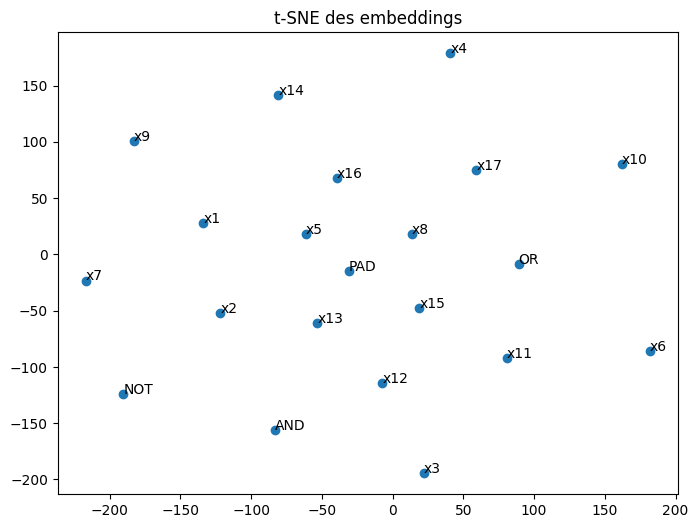

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from pysat.formula import CNF
from pysat.solvers import Solver
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1" #Pour éviter crash session


# Utiliser GPU si disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Chargement des instances
def load_satlib(directory, max_instances=None):
    files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.cnf')]
    if max_instances:
        files = files[:max_instances]
    instances = []
    for path in files:
        formula = CNF(from_file=path)
        formula.path = path
        instances.append(formula)
    return instances

# 2. Construction du vocabulaire dynamique
SPECIAL = ['PAD', 'AND', 'OR', 'NOT']

def build_vocab(instances):
    vars_set = set()
    for formula in instances:
        for clause in formula.clauses:
            for lit in clause:
                vars_set.add(abs(lit))
    vars_list = sorted(vars_set)
    token2id = {tok: idx for idx, tok in enumerate(SPECIAL)}
    for v in vars_list:
        token2id[f'x{v}'] = len(token2id)
    id2token = {i: t for t, i in token2id.items()}
    return token2id, id2token

# 3. Conversion d'une formule CNF en séquence de tokens
MAX_LEN = 500

def formula_to_tokens(formula, token2id, max_len=MAX_LEN):
    tokens = []
    for i, clause in enumerate(formula.clauses):
        for j, lit in enumerate(clause):
            if lit < 0:
                tokens.append('NOT')
            tokens.append(f'x{abs(lit)}')
            if j < len(clause) - 1:
                tokens.append('OR')
        if i < len(formula.clauses) - 1:
            tokens.append('AND')
    ids = [token2id.get(t, token2id['PAD']) for t in tokens][:max_len]
    pad = [token2id['PAD']] * (max_len - len(ids))
    return torch.tensor(ids + pad, dtype=torch.long)

# 4. Génération du dataset avec labels par pySAT
def make_dataset(instances, token2id):
    dataset = []
    for formula in instances:
        x_ids = formula_to_tokens(formula, token2id)
        with Solver(name='g3') as solver:
            solver.append_formula(formula.clauses)
            sat = solver.solve()
        label = int(sat)
        dataset.append((formula, x_ids, label))
    return dataset

# 5. Dataset pour DataLoader
class SATDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        _, x_ids, label = self.data[idx]
        return x_ids, torch.tensor(label, dtype=torch.float)

# 6. Modèle Transformer avec masque de padding
class AttentionLayer(nn.Module):
    def __init__(self, dim, heads, dropout=0.0):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads,
                                          dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(dim)

    def forward(self, x, key_padding_mask=None):
        out, weights = self.attn(x, x, x,
                                 key_padding_mask=key_padding_mask,
                                 need_weights=True)
        out = self.dropout(out)
        return self.ln(out + x), weights

class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size, pad_id, hidden_dim=64, n_heads=2, seq_len=MAX_LEN, dropout=0.0):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_id)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, hidden_dim))
        self.embed_dropout = nn.Dropout(dropout)
        self.attn_layer = AttentionLayer(hidden_dim, n_heads, dropout)
        self.ff = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(hidden_dim, 1)
        self.attn_map = None

    def forward(self, x_ids):
        key_padding_mask = (x_ids == self.pad_id)
        x = self.embedding(x_ids) + self.pos_embedding[:, :x_ids.size(1), :]
        x = self.embed_dropout(x)
        x, attn_w = self.attn_layer(x, key_padding_mask=key_padding_mask)
        self.attn_map = attn_w.detach().cpu()
        x = self.ff(x)
        x = x.mean(dim=1)
        return self.classifier(x).squeeze(-1)

# 7. Fonction d'évaluation avec DataLoader
def evaluate(model, data_loader, loss_fn):
    model.eval()
    total, correct = 0, 0
    total_loss = 0
    with torch.no_grad():
        for x_ids_batch, labels_batch in data_loader:
            x = x_ids_batch.to(device)
            y_true = labels_batch.to(device)
            y_logits = model(x)
            y_pred = torch.sigmoid(y_logits)
            loss = loss_fn(y_logits, y_true)
            total_loss += loss.item() * x.size(0)
            correct += ((y_pred > 0.5).float() == y_true).sum().item()
            total += x.size(0)
    acc = correct / total
    avg_loss = total_loss / total
    return acc, avg_loss

# 8. Entraînement et évaluation
if __name__ == '__main__':
    satlib_dir = '/content/generated_3sat'
    instances = load_satlib(satlib_dir, max_instances=10000)
    token2id, id2token = build_vocab(instances)
    vocab_size = len(token2id)
    dataset = make_dataset(instances, token2id)

    # Split train / val / test
    random_order = torch.randperm(len(dataset))
    n_total = len(dataset)
    n_train = int(0.8 * n_total)
    n_val = int(0.1 * n_total)

    train_data = [dataset[i] for i in random_order[:n_train]]
    val_data   = [dataset[i] for i in random_order[n_train:n_train + n_val]]
    test_data  = [dataset[i] for i in random_order[n_train + n_val:]]

    # DataLoaders
    BATCH_SIZE = 32
    train_loader = DataLoader(SATDataset(train_data), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    val_loader   = DataLoader(SATDataset(val_data),   batch_size=BATCH_SIZE, pin_memory=True)
    test_loader  = DataLoader(SATDataset(test_data),  batch_size=BATCH_SIZE, pin_memory=True)

    print(f"Train : {len(train_data)}, Val : {len(val_data)}, Test : {len(test_data)}")
    from collections import Counter
    labels = [label for _, _, label in dataset]
    print(Counter(labels))

    # Initialisation du modèle
    model = SimpleTransformer(vocab_size=vocab_size, pad_id=token2id['PAD']).to(device)
    loss_fn = nn.BCEWithLogitsLoss()
    opt = torch.optim.Adam(model.parameters(), lr=1e-5)

    # Baseline avant entraînement
    baseline_acc, baseline_loss = evaluate(model, val_loader, loss_fn)
    print(f"Baseline (poids initiaux) : {baseline_acc:.4f} | Loss : {baseline_loss:.4f}")

    best_score = -float('inf')
    patience = 3
    counter = 0
    best_model = None

    for epoch in range(10):
        model.train()
        total_loss = 0
        for x_ids_batch, labels_batch in train_loader:
            x = x_ids_batch.to(device)
            y_true = labels_batch.to(device)
            y_logits = model(x)
            loss = loss_fn(y_logits, y_true)
            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            total_loss += loss.item() * x.size(0)

        val_acc, val_loss = evaluate(model, val_loader, loss_fn)
        avg_train_loss = total_loss / len(train_loader.dataset)
        print(f"Époque {epoch+1} | Training Loss : {avg_train_loss:.4f} | Validation accuracy : {val_acc:.4f} | Validation loss : {val_loss:.4f}")

        score = val_acc - val_loss
        if score > best_score:
            best_score = score
            counter = 0
            best_model = model.state_dict()
            print(f"  → Nouveau meilleur score composite : {best_score:.4f} (acc {val_acc:.4f}, loss {val_loss:.4f})")
        else:
            counter += 1
            print(f"  → Pas d'amélioration du score composite ({counter}/{patience} époques sans progrès)")
            if counter >= patience:
                print("Early stopping déclenché.")
                break

    # Évaluation finale
    model.load_state_dict(best_model)
    test_acc, test_loss = evaluate(model, test_loader, loss_fn)
    print(f"\nPrécision finale sur test : {test_acc:.4f} | Perte : {test_loss:.4f}\n")

    #Sauvegarde du meilleur modèle
    torch.save({
      'model_state_dict': model.state_dict(),
     'token2id': token2id,
      'id2token': id2token
    }, 'transformer_sat.pt')

    # Afficher les 10 dernières formules testées
    print("10 dernières formules testées :\n")
    for formula, x_ids, label in test_data[-10:]:
        x = x_ids.unsqueeze(0).to(device)
        with torch.no_grad():
            pred = torch.sigmoid(model(x)).item()
        sat_pred = 1 if pred > 0.5 else 0
        print(f"Formule : {os.path.basename(formula.path)}")
        print(f"  – Label réel : {label}, Probabilité SAT : {pred:.4f}, Prédiction binaire : {sat_pred}")
        print("-" * 60)

    # Visualisation de l'attention & embeddings
    sample = test_data[0][1].unsqueeze(0)
    _ = model(sample.to(device))
    attn_head = model.attn_map[0].numpy()
    full_tokens = [id2token[int(i)] for i in sample[0]]
    token_indices = [i for i, t in enumerate(full_tokens) if t != 'PAD']
    labels = [full_tokens[i] for i in token_indices]
    attn_trim = attn_head[np.ix_(token_indices, token_indices)]

    N = len(labels)
    fig, ax = plt.subplots(figsize=(max(6, N*0.5), max(6, N*0.5)))
    cax = ax.matshow(attn_trim, aspect='equal', interpolation='nearest')
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(N))
    ax.set_yticks(range(N))
    ax.set_xticklabels(labels, rotation=90, fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_title('Self-Attention (tête 0) – tokens non-PAD', fontsize=12)
    plt.tight_layout()
    plt.show()

    emb = model.embedding.weight.data.cpu().numpy()
    tsne = TSNE(n_components=2, perplexity=5, random_state=42)
    emb2d = tsne.fit_transform(emb)
    plt.figure(figsize=(8,6))
    plt.scatter(emb2d[:,0], emb2d[:,1])
    for i, tok in id2token.items():
        plt.text(emb2d[i,0]+0.1, emb2d[i,1]+0.1, tok)
    plt.title('t-SNE des embeddings')
    plt.show()


# **Transformer Utilisation**

 Charge le modèle Transformer depuis transformer_sat.pt, traite une instance SAT de /content/generated_3sat et prédit si elles sont satisfaisables ou non, avec une probabilité.

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pysat.formula import CNF

MODEL_PATH = '/content/transformer_sat.pt'
SAT_DIR = '/content/generated_3sat'
MAX_LEN = 500

# Modèle d'attention
class AttentionLayer(nn.Module):
    def __init__(self, dim, heads, dropout=0.0):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(dim)

    def forward(self, x, key_padding_mask=None):
        out, weights = self.attn(x, x, x, key_padding_mask=key_padding_mask, need_weights=True)
        out = self.dropout(out)
        return self.ln(out + x), weights

# Transformer simplifié
class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size, pad_id, hidden_dim=64, n_heads=2, seq_len=MAX_LEN, dropout=0.0):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, hidden_dim, padding_idx=pad_id)
        self.pos_embedding = nn.Parameter(torch.randn(1, seq_len, hidden_dim))  # Optionnel si problème mémoire
        self.embed_dropout = nn.Dropout(dropout)
        self.attn_layer = AttentionLayer(hidden_dim, n_heads, dropout)
        self.ff = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(dropout)
        )
        self.classifier = nn.Linear(hidden_dim, 1)
        self.attn_map = None

    def forward(self, x_ids):
        key_padding_mask = (x_ids == self.pad_id)
        x = self.embedding(x_ids) + self.pos_embedding[:, :x_ids.size(1), :]
        x = self.embed_dropout(x)
        x, attn_w = self.attn_layer(x, key_padding_mask=key_padding_mask)
        self.attn_map = attn_w.detach().cpu()
        x = self.ff(x)
        x = x.mean(dim=1)
        return self.classifier(x).squeeze(-1)

# Chargement modèle
checkpoint = torch.load(MODEL_PATH, map_location='cpu')
token2id = checkpoint['token2id']
id2token = checkpoint['id2token']
vocab_size = len(token2id)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleTransformer(vocab_size=vocab_size, pad_id=token2id['PAD'])
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

# Conversion formule vers tokens
def formula_to_tokens(formula, token2id, max_len=MAX_LEN):
    tokens = []
    for i, clause in enumerate(formula.clauses):
        for j, lit in enumerate(clause):
            if lit < 0:
                tokens.append('NOT')
            tokens.append(f'x{abs(lit)}')
            if j < len(clause) - 1:
                tokens.append('OR')
        if i < len(formula.clauses) - 1:
            tokens.append('AND')
    ids = [token2id.get(t, token2id['PAD']) for t in tokens][:max_len]
    pad = [token2id['PAD']] * (max_len - len(ids))
    return torch.tensor(ids + pad, dtype=torch.long)

# Lecture de la première formule
files = sorted([f for f in os.listdir(SAT_DIR) if f.endswith('.cnf')])
if len(files) == 0:
    raise ValueError("Aucune instance trouvée :(")

filename = files[0]
path = os.path.join(SAT_DIR, filename)
formula = CNF(from_file=path)

x_ids = formula_to_tokens(formula, token2id).unsqueeze(0).to(device)
with torch.no_grad():
    logit = model(x_ids)
    prob = torch.sigmoid(logit).item()
    prediction = 1 if prob > 0.5 else 0

print(f"Formule: {filename}")
print(f"  – Proba SAT: {prob:.4f}")
print(f"  – Prédiction: {'SATISFIABLE' if prediction else 'INSATISFIABLE'}")

# Heatmap d'attention (tête 0)
attn_head = model.attn_map[0].numpy()
tokens = [id2token[int(tok)] for tok in x_ids[0]]
indices = [i for i, t in enumerate(tokens) if t != 'PAD']
labels = [tokens[i] for i in indices]
attn_trimmed = attn_head[np.ix_(indices, indices)]

N = len(labels)
fig, ax = plt.subplots(figsize=(max(6, N*0.4), max(6, N*0.4)))
cax = ax.matshow(attn_trimmed, aspect='auto', cmap='viridis')
fig.colorbar(cax)
ax.set_xticks(range(N))
ax.set_yticks(range(N))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title('Self-Attention Heatmap (instance 1)', fontsize=12)
plt.tight_layout()
plt.show()

# Libération mémoire
del model, x_ids, formula, attn_head
torch.cuda.empty_cache()


Formule: instance_0_SAT.cnf
  – Proba SAT: 0.4928
  – Prédiction: INSATISFIABLE
